# Snow Drift Exposure Analysis

This notebook identifies which road segments are exposed to **snow drift zones** by overlaying known snowdrift-prone areas onto Serbia's road network.

**Key steps:**
1. Load the road network and snow drift zone data
2. Visualise snowdrift zones by drift length
3. Spatial join — find which roads intersect snowdrift zones
4. Visualise exposed road segments
5. Save results as ArcGIS layers

> **Note:** Unlike the flood analysis, snow drift data comes as vector features (line segments marking drift-prone sections). The key attribute is `dužina_sn` — the length of the snowdrift-prone section in kilometers.

## Step 1: Setup and Imports

In [35]:
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

warnings.simplefilter(action="ignore", category=FutureWarning)

### Helper functions

In [37]:
# Helper functions

def save_lyrx_layer(gdf, gpkg_path, lyrx_path, layer_name, labels, colors, width_mapping, field, title=None):
    """Save GeoDataFrame to GeoPackage + ArcGIS Pro .lyrx with unique-value symbology."""
    import json as _json

    gdf.to_file(gpkg_path, driver="GPKG", layer=layer_name)
    print(f"Saved GeoPackage → {gpkg_path}")

    try:
        import arcpy
    except ImportError:
        print("arcpy not available — .lyrx skipped. GeoPackage was saved successfully.")
        return

    title = title or layer_name
    gpkg_layer_path = str(gpkg_path.absolute()) + f"/{layer_name}"
    tmp_layer_name = f"tmp_lyr_{layer_name}"
    arcpy.management.MakeFeatureLayer(gpkg_layer_path, tmp_layer_name)
    tmp_lyrx = lyrx_path.with_suffix(".tmp.lyrx")
    arcpy.management.SaveToLayerFile(tmp_layer_name, str(tmp_lyrx), "ABSOLUTE")
    arcpy.management.Delete(tmp_layer_name)

    with open(tmp_lyrx) as f:
        lyrx = _json.load(f)

    def _make_symbol(hex_color, width):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return {
            "type": "CIMSymbolReference",
            "symbol": {
                "type": "CIMLineSymbol",
                "symbolLayers": [{
                    "type": "CIMSolidStroke", "enable": True,
                    "capStyle": "Round", "joinStyle": "Round",
                    "width": width,
                    "color": {"type": "CIMRGBColor", "values": [r, g, b, 100]},
                }],
            },
        }

    renderer = {
        "type": "CIMUniqueValueRenderer",
        "defaultLabel": "<all other values>",
        "defaultSymbolPatch": "Default",
        "defaultSymbol": _make_symbol("#cccccc", 0.5),
        "defaultSymbolVisible": False,
        "fields": [field],
        "groups": [{
            "type": "CIMUniqueValueGroup",
            "classes": [
                {
                    "type": "CIMUniqueValueClass",
                    "label": label, "patch": "Default",
                    "symbol": _make_symbol(color, width_mapping.get(label, 1.0)),
                    "values": [{"type": "CIMUniqueValue", "fieldValues": [label]}],
                    "visible": True,
                }
                for label, color in zip(labels, colors)
            ],
            "heading": field,
        }],
        "useDefaultSymbol": False,
    }

    lyrx["layerDefinitions"][0]["renderer"] = renderer
    lyrx["layerDefinitions"][0]["name"] = title

    with open(lyrx_path, "w") as f:
        _json.dump(lyrx, f, indent=2)

    tmp_lyrx.unlink()
    print(f"Saved layer file → {lyrx_path}")

### Define file paths

In [39]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

# Create output directories if they don't exist
figure_path.mkdir(parents=True, exist_ok=True)
arcgis_results.mkdir(parents=True, exist_ok=True)
arcgis_gpkg.mkdir(parents=True, exist_ok=True)

## Step 2: Load Data

### Road network and country boundary

In [41]:
# Load road network
roads = gpd.read_file(data_path / "DeoniceRSDP-Jul2025..shp")
print(f"Road segments loaded: {len(roads):,}")
print(f"CRS: {roads.crs}")

# Load country outline (for plotting)
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_plot = world.loc[world.SOV_A3 == 'SRB']
# Clip to Serbia only (remove Kosovo roads)
roads = gpd.clip(roads, country_plot.to_crs(roads.crs))


Road segments loaded: 2,023
CRS: EPSG:4326


### Snow drift zones

The snowdrift data comes from historical studies mapping sections of roads prone to snow accumulation.

In [43]:
snow_drift = gpd.read_file(data_path / "snezni_nanosi_studije.shp")

print(f"Snow drift zones loaded: {len(snow_drift):,}")
print(f"CRS: {snow_drift.crs}")
print(f"\nSnow drift length (dužina_sn) statistics:")
print(snow_drift['dužina_sn'].describe().round(2))

Snow drift zones loaded: 787
CRS: EPSG:6316

Snow drift length (dužina_sn) statistics:
count    787.00
mean       2.82
std        3.73
min        0.01
25%        0.50
50%        1.50
75%        3.44
max       26.48
Name: dužina_sn, dtype: float64


## Step 3: Visualise Snow Drift Zones

We classify snowdrift zones by their length (in km) — longer drift sections pose a greater risk to road accessibility.

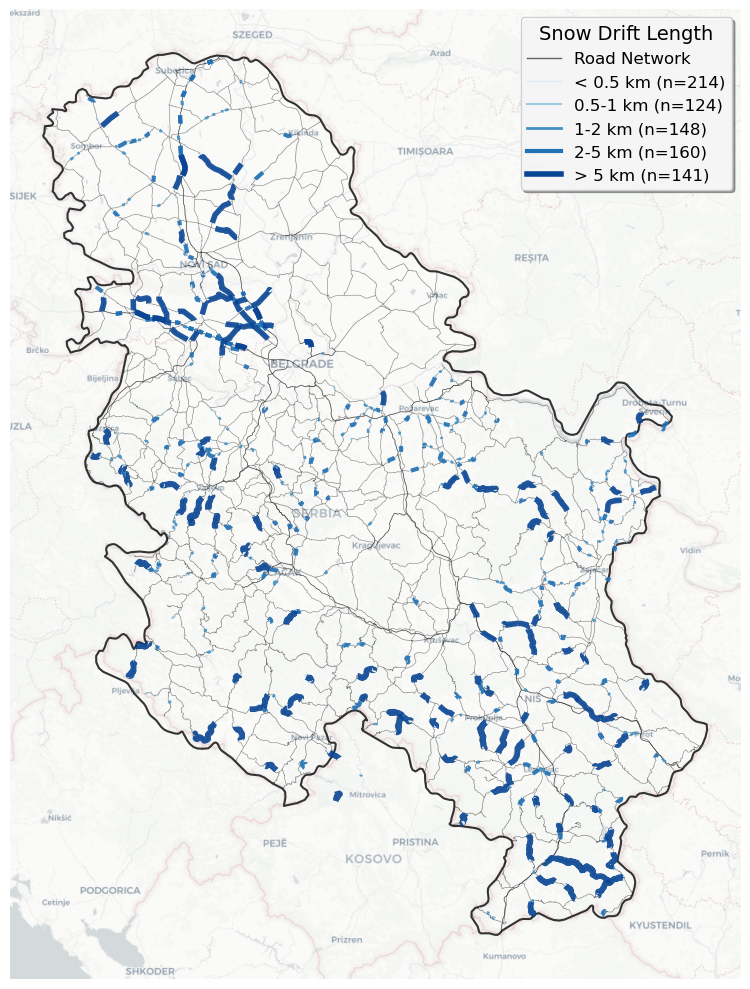

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Convert to Web Mercator for basemap
serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads.to_crs(3857)
snow_drift_mercator = snow_drift.to_crs(3857)

# Classify by drift length
bins = [0, 0.5, 1, 2, 5, float('inf')]
labels = ['< 0.5 km', '0.5-1 km', '1-2 km', '2-5 km', '> 5 km']
snow_drift_mercator['length_class'] = pd.cut(
    snow_drift_mercator['dužina_sn'],
    bins=bins, labels=labels, include_lowest=True
)

# Graduated colours and linewidths — longer = thicker/darker
colors = {
    '< 0.5 km': '#deebf7',
    '0.5-1 km': '#9ecae1',
    '1-2 km': '#4292c6',
    '2-5 km': '#2171b5',
    '> 5 km': '#084594'
}
linewidths = {
    '< 0.5 km': 1.0,
    '0.5-1 km': 1.5,
    '1-2 km': 2.0,
    '2-5 km': 3.0,
    '> 5 km': 4.0
}

# Country outline
serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                     linewidth=1.5, zorder=2)

# Road network (background)
roads_mercator.plot(ax=ax, color='black', linewidth=0.4,
                    alpha=0.5, zorder=2)

# Snow drift zones by length class
for length_class in labels:
    subset = snow_drift_mercator[snow_drift_mercator['length_class'] == length_class]
    if len(subset) > 0:
        subset.plot(ax=ax, color=colors[length_class],
                    linewidth=linewidths[length_class],
                    alpha=0.9, zorder=3)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)
ax.set_aspect('equal')
ax.axis('off')

# Legend with counts per class
legend_elements = [
    Line2D([0], [0], color='black', linewidth=1, label='Road Network', alpha=0.6)
] + [
    Line2D([0], [0], color=colors[label], linewidth=linewidths[label],
           label=f'{label} (n={len(snow_drift_mercator[snow_drift_mercator["length_class"] == label])})')
    for label in labels
]
ax.legend(handles=legend_elements, title='Snow Drift Length', loc='upper right',
          fontsize=12, title_fontsize=14,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'snow_drift_map.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Identify Exposed Roads

We use a **spatial join** to find all road segments that intersect with a snowdrift zone. Roads that cross multiple zones may appear more than once, so we aggregate to keep the maximum snowdrift length per road.

In [49]:
# Ensure matching CRS
snow_drift_join = snow_drift.to_crs(roads.crs)

# Spatial join: find roads that intersect snowdrift zones
roads_snowdrift = roads.sjoin(snow_drift_join, how="inner", predicate="intersects")

print(f"Road-snowdrift matches (before dedup): {len(roads_snowdrift):,}")

# A road can intersect multiple snowdrift zones — keep the max drift length per road
snowdrift_per_road = roads_snowdrift.groupby(roads_snowdrift.index)['dužina_sn'].max()

# Tag all roads
roads['snowdrift_exposed'] = roads.index.isin(snowdrift_per_road.index)
roads['snowdrift_length'] = snowdrift_per_road
roads['snowdrift_length'] = roads['snowdrift_length'].fillna(0)

n_exposed = roads['snowdrift_exposed'].sum()
n_total = len(roads)
print(f"\nExposed road segments: {n_exposed:,} ({n_exposed / n_total * 100:.1f}%)")
print(f"Not exposed:           {n_total - n_exposed:,}")

Road-snowdrift matches (before dedup): 432

Exposed road segments: 315 (17.2%)
Not exposed:           1,513


### Visualise exposed road segments

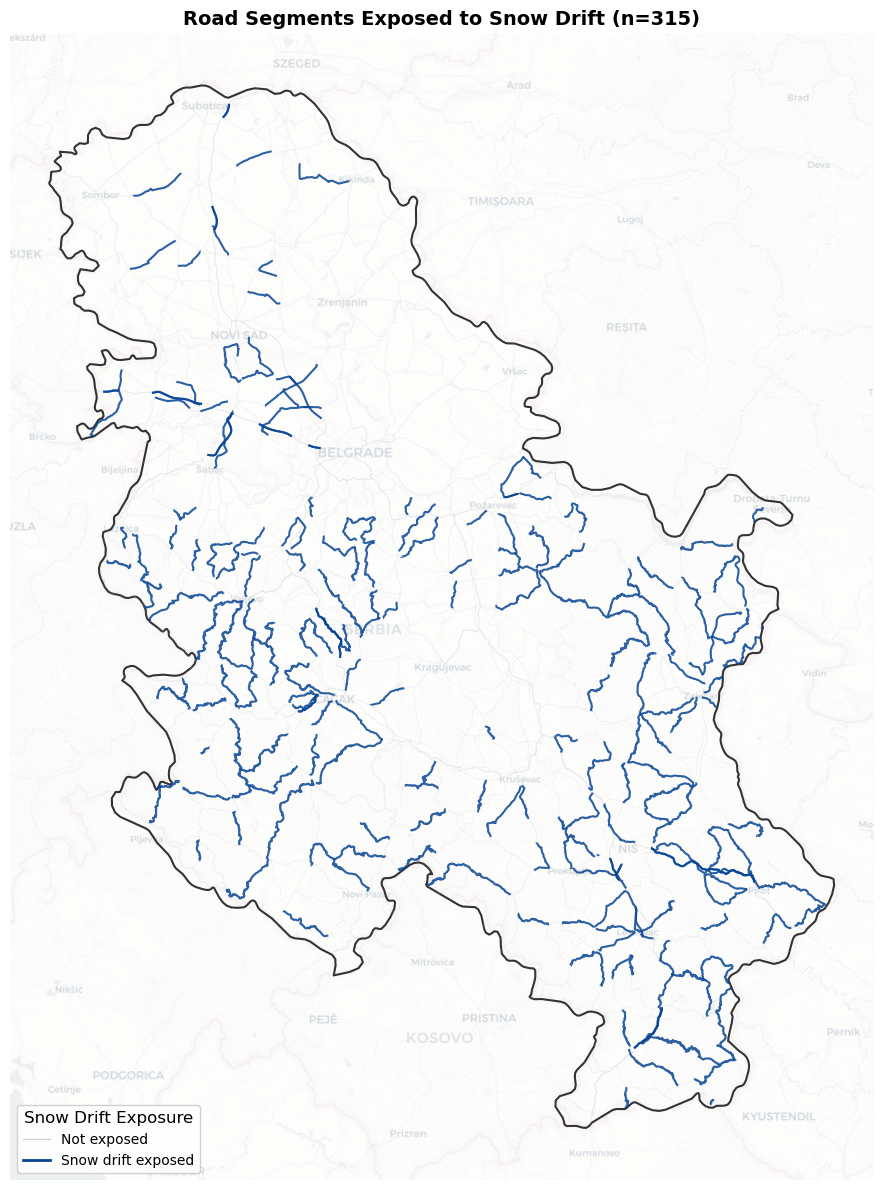

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads.to_crs(3857)

# Country outline
serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                     linewidth=1.5, zorder=1)

# Not exposed (grey)
roads_mercator[~roads_mercator['snowdrift_exposed']].plot(
    ax=ax, color='#d3d3d3', linewidth=0.3, alpha=0.4, zorder=1
)

# Exposed (dark blue)
roads_mercator[roads_mercator['snowdrift_exposed']].plot(
    ax=ax, color='#084594', linewidth=1.5, alpha=0.85, zorder=2
)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron,
               alpha=0.4, attribution=False)
ax.axis('off')

legend_handles = [
    Line2D([0], [0], color='#d3d3d3', lw=1, label='Not exposed'),
    Line2D([0], [0], color='#084594', lw=2, label='Snow drift exposed'),
]
ax.legend(handles=legend_handles, title="Snow Drift Exposure",
          loc="lower left", fontsize=10, title_fontsize=12,
          frameon=True, fancybox=True, framealpha=0.9,
          facecolor='white', edgecolor='#cccccc')

ax.set_title(f"Road Segments Exposed to Snow Drift (n={n_exposed:,})",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(figure_path / 'snowdrift_exposure_roads.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5: Save Results as ArcGIS Layers

The results are saved as a GeoPackage and ArcGIS Pro layer file. Open the `.lyrx` file in ArcGIS Pro to see the results on your map.

In [53]:
roads['snow_class'] = np.where(roads['snowdrift_exposed'], "Snow drift zone", "Not exposed")

save_lyrx_layer(
    gdf=roads,
    gpkg_path=arcgis_gpkg / "snowdrift_exposure_roads.gpkg",
    lyrx_path=arcgis_results / "snowdrift_exposure_roads.lyrx",
    layer_name="snowdrift_exposure_roads",
    labels=["Not exposed", "Snow drift zone"],
    colors=["#d3d3d3", "#084594"],
    width_mapping={"Not exposed": 0.3, "Snow drift zone": 1.5},
    field="snow_class",
    title="Snow Drift Exposure on Roads",
)

print("\n✅ Done! Open 'snowdrift_exposure_roads.lyrx' in ArcGIS Pro to view the results.")

Saved GeoPackage → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\Geopackages\snowdrift_exposure_roads.gpkg
Saved layer file → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\snowdrift_exposure_roads.lyrx

✅ Done! Open 'snowdrift_exposure_roads.lyrx' in ArcGIS Pro to view the results.
